# Minimal TensorFlow Introduction

This notebook supports Day 1 Tutorial 1:

```text
Getting Started with TensorFlow / PyTorch / JAX and Hands-on Practice
```

Purpose: this notebook is distributed around noon as TensorFlow preparation and review. It is not a full deep-learning course. It introduces only the tools needed to read the MMW and Krusell-Smith code.

Before running this notebook, follow `01_Setup_and_Run_Guide.md` and confirm that your local notebook environment works. If setup errors remain, you may use AI tools to help with installation and interpret the error message; if it still does not work, ask TA Peiyuan Zhang during a break.

Suggested use:

- Around noon / before class: students with prior background can use it as a refresher; students without TensorFlow experience can preview the first sections.
- At the beginning of the tutorial: the instructor can briefly walk through the key cells while students run them in parallel.
- In the main part of the tutorial: these concepts will be used to understand residuals, loss functions, and training loops in notebooks 03 and 04.

Run level: Sections 0-9 are recommended for in-class execution; Section 10 is an optional TensorFlow / PyTorch / JAX comparison; Section 11 prepares the transition to the MMW / KS code.

The main track is TensorFlow. PyTorch and JAX are optional comparisons.


## 0. Learning Goals

After this notebook, students should know the following before moving to notebooks 03 and 04:

1. How to check whether TensorFlow is available.
2. What tensor, shape, and dtype mean.
3. The difference between `tf.Variable` and `tf.constant`.
4. How to use `tf.GradientTape` for automatic differentiation.
5. How an optimizer minimizes a loss.
6. How numerical solvers and neural-network training share the same residual-reduction logic.
7. How a neural network can approximate an unknown function.
8. Why the model code often follows `state -> neural network -> decision -> residual -> loss -> optimizer step`.


In [1]:
# If this cell fails, check 01_Setup_and_Run_Guide.md first. 
# You may use AI tools to help with installation and interpret the error; if it still fails, ask TA Peiyuan Zhang during a break.
import sys
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("TensorFlow:", tf.__version__)


Python: 3.13.7
NumPy: 2.2.4
TensorFlow: 2.21.0


## 1. Tensor, Shape, and dtype

A tensor is the deep-learning framework's array object.

We will often check two things:

- `shape`: dimensions, for example `(n, 1)` means n samples with one feature each.
- `dtype`: data type, for example `float32`. Deep-learning code usually uses `float32`.


In [2]:
# Scalar, vector, and matrix
scalar = tf.constant(2.0)
vector = tf.constant([1.0, 2.0, 3.0])
matrix = tf.constant([[1.0, 2.0], [3.0, 4.0]])

for name, obj in [("scalar", scalar), ("vector", vector), ("matrix", matrix)]:
    print(name)
    print("  value:", obj.numpy())
    print("  shape:", obj.shape)
    print("  dtype:", obj.dtype)


scalar
  value: 2.0
  shape: ()
  dtype: <dtype: 'float32'>
vector
  value: [1. 2. 3.]
  shape: (3,)
  dtype: <dtype: 'float32'>
matrix
  value: [[1. 2.]
 [3. 4.]]
  shape: (2, 2)
  dtype: <dtype: 'float32'>


In [3]:
# NumPy arrays and TensorFlow tensors can be converted back and forth.
x_np = np.array([[1.0], [2.0], [3.0]], dtype=np.float32)
x_tf = tf.constant(x_np)

print(type(x_np), x_np.shape)
print(type(x_tf), x_tf.shape)
print(x_tf.numpy())


<class 'numpy.ndarray'> (3, 1)
<class 'tensorflow.python.framework.ops.EagerTensor'> (3, 1)
[[1.]
 [2.]
 [3.]]


## 2. Common Tensor Operations

MMW / KS code often uses:

- addition, subtraction, multiplication, and division;
- mean and sum;
- concatenating variables;
- matrix multiplication;
- parallel computation over a batch of samples.


In [4]:
a = tf.constant([[1.0], [2.0], [3.0]])
b = tf.constant([[4.0], [5.0], [6.0]])

print("a + b:\n", (a + b).numpy())
print("a * b:\n", (a * b).numpy())
print("mean(a):", tf.reduce_mean(a).numpy())
print("sum(a):", tf.reduce_sum(a).numpy())

# Concatenate two state variables, for example state = (k, z).
state = tf.concat([a, b], axis=1)
print("state shape:", state.shape)
print(state.numpy())


a + b:
 [[5.]
 [7.]
 [9.]]
a * b:
 [[ 4.]
 [10.]
 [18.]]
mean(a): 2.0
sum(a): 6.0
state shape: (3, 2)
[[1. 4.]
 [2. 5.]
 [3. 6.]]


In [5]:
# Matrix multiplication: a neural-network linear layer is essentially x @ W + b.
x = tf.constant([[1.0, 2.0], [3.0, 4.0]])
W = tf.constant([[0.5], [2.0]])
bias = tf.constant([1.0])

print("x @ W + b =\n", (tf.matmul(x, W) + bias).numpy())


x @ W + b =
 [[ 5.5]
 [10.5]]


## 3. `tf.constant` and `tf.Variable`

- `tf.constant`: a fixed object, such as data, parameter values, or state samples.
- `tf.Variable`: a trainable or updateable object, such as neural-network weights.

If an object will be updated by gradient descent, it is usually a `tf.Variable`.


In [6]:
theta = tf.Variable(-3.0)
print("initial theta:", theta.numpy())

theta.assign(1.5)
print("after assign:", theta.numpy())


initial theta: -3.0
after assign: 1.5


## 4. Automatic Differentiation with `tf.GradientTape`

Automatic differentiation is one of the main reasons deep-learning frameworks are useful.

Once we write down a loss, TensorFlow can compute its gradient with respect to the parameters.


In [7]:
theta = tf.Variable(0.0)

with tf.GradientTape() as tape:
    loss = (theta - 2.0) ** 2

grad = tape.gradient(loss, theta)
print("loss:", loss.numpy())
print("gradient dloss/dtheta:", grad.numpy())


loss: 4.0
gradient dloss/dtheta: -4.0


## 5. Optimizer: From Gradients to Updates

After gradients are available, the optimizer updates parameters.

The example below asks TensorFlow to learn one scalar parameter:

\[
\min_\theta (\theta - 2)^2.
\]

This is simple, but the logic is the same as training a neural network.


learned theta: 1.9439687
final loss: 0.004534533247351646


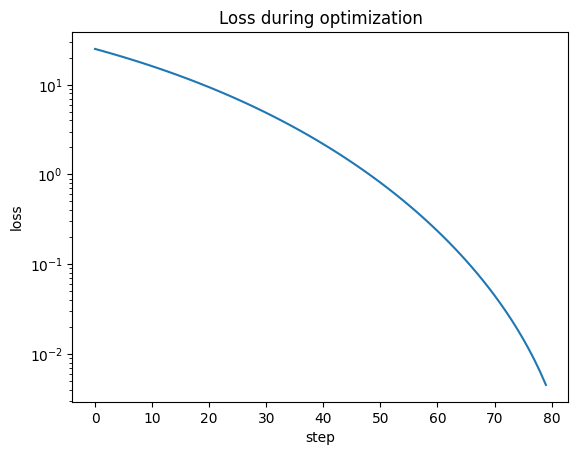

In [8]:
theta = tf.Variable(-3.0)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.1)

history = []
for step in range(80):
    with tf.GradientTape() as tape:
        loss = (theta - 2.0) ** 2
    grad = tape.gradient(loss, theta)
    optimizer.apply_gradients([(grad, theta)])
    history.append(float(loss.numpy()))

print("learned theta:", theta.numpy())
print("final loss:", history[-1])

plt.plot(history)
plt.yscale("log")
plt.title("Loss during optimization")
plt.xlabel("step")
plt.ylabel("loss")
plt.show()


### 5.1 Numerical Solvers and Neural-Network Training: Same Residual Logic

Many students have seen numerical methods such as Newton or quasi-Newton methods. The useful connection is:

```text
choose unknown object -> compute residual/error -> use derivatives to reduce the residual
```

For a root-finding problem, we may want to solve:

$$
R(\theta)=\theta^2-2=0.
$$

Newton's method uses the derivative/Jacobian explicitly:

$$
\theta_{new}=\theta-\frac{R(\theta)}{R'(\theta)}.
$$

Gradient descent instead minimizes a residual loss:

$$
L(\theta)=R(\theta)^2.
$$

In larger neural-network problems, `theta` is no longer one number. It is a long vector of neural-network weights. The residual is evaluated over many states, and TensorFlow computes the gradient of the average residual loss automatically. This is not exactly Newton's method, but the derivative logic is closely related.


Newton final theta: 1.414213562373095
Gradient descent final theta: 1.4142135381698608
True sqrt(2): 1.4142135623730951


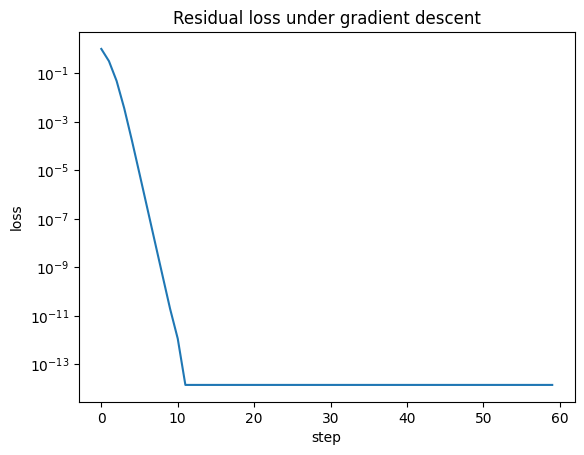

In [9]:
# Same residual, two solution styles: Newton root solving vs. residual gradient descent.

# Route A: Newton method for R(theta) = theta^2 - 2 = 0.
theta_newton = 1.0
newton_path = []

for step in range(6):
    residual = theta_newton ** 2 - 2.0
    jacobian = 2.0 * theta_newton
    newton_path.append((step, theta_newton, residual))
    theta_newton = theta_newton - residual / jacobian

# Route B: TensorFlow gradient descent on L(theta) = R(theta)^2.
theta_gd = tf.Variable(1.0)
optimizer = tf.keras.optimizers.SGD(learning_rate=0.05)
gd_loss = []

for step in range(60):
    with tf.GradientTape() as tape:
        residual = theta_gd ** 2 - 2.0
        loss = residual ** 2
    grad = tape.gradient(loss, theta_gd)
    optimizer.apply_gradients([(grad, theta_gd)])
    gd_loss.append(float(loss.numpy()))

print("Newton final theta:", theta_newton)
print("Gradient descent final theta:", float(theta_gd.numpy()))
print("True sqrt(2):", float(np.sqrt(2.0)))

plt.plot(gd_loss)
plt.yscale("log")
plt.title("Residual loss under gradient descent")
plt.xlabel("step")
plt.ylabel("loss")
plt.show()


## 6. Neural Networks as Function Approximators

In economic models, many objects are unknown functions, such as:

- policy functions;
- decision rules;
- value functions;
- forecasting rules.

Deep-learning methods often represent these unknown functions with neural networks:

```text
state variables -> neural network -> decision variables
```


In [10]:
# A minimal neural network: one-dimensional input x and one-dimensional output y.
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation="tanh", input_shape=(1,)),
    tf.keras.layers.Dense(16, activation="tanh"),
    tf.keras.layers.Dense(1)
])

model.summary()


d:\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Example A: Learning an Unknown Function from Data

This example mimics a supervised-learning setting: we observe data and estimate an unknown function.

The true function is:

\[
y = f(x) + \varepsilon, \quad f(x) = \sin(2x) + 0.3x.
\]

Focus on three steps:

1. Generate data.
2. Define a neural network.
3. Train it and plot the estimated function.


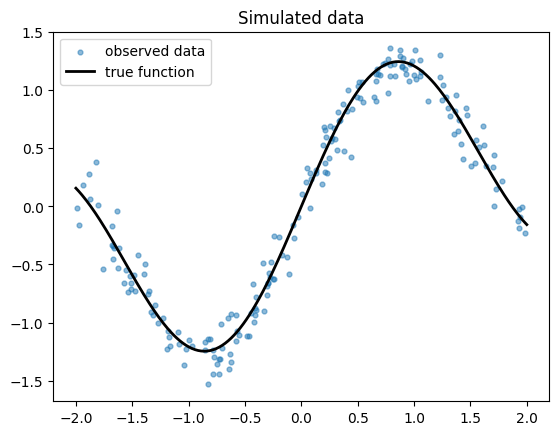

In [11]:
# Generate simulated data
np.random.seed(123)

n_train = 200
x_train = np.random.uniform(-2.0, 2.0, size=(n_train, 1)).astype(np.float32)
y_true = np.sin(2.0 * x_train) + 0.3 * x_train
noise = 0.15 * np.random.randn(n_train, 1).astype(np.float32)
y_train = y_true + noise

x_grid = np.linspace(-2.0, 2.0, 300).reshape(-1, 1).astype(np.float32)
y_grid_true = np.sin(2.0 * x_grid) + 0.3 * x_grid

plt.scatter(x_train, y_train, s=12, alpha=0.5, label="observed data")
plt.plot(x_grid, y_grid_true, color="black", linewidth=2, label="true function")
plt.legend()
plt.title("Simulated data")
plt.show()


In [12]:
# Define and train the neural network.
# This is supervised learning: y_train is the observed label.
fn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation="tanh", input_shape=(1,)),
    tf.keras.layers.Dense(32, activation="tanh"),
    tf.keras.layers.Dense(1)
])

fn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="mse"
)

history = fn_model.fit(x_train, y_train, epochs=400, verbose=0)
print("final training loss:", history.history["loss"][-1])


final training loss: 0.024811966344714165


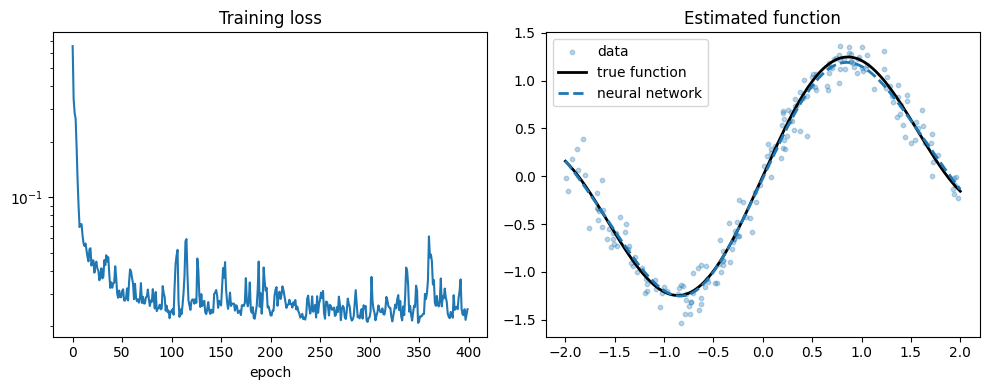

In [13]:
# Plot the function estimated by the neural network.
y_pred = fn_model.predict(x_grid, verbose=0)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"])
plt.yscale("log")
plt.title("Training loss")
plt.xlabel("epoch")

plt.subplot(1, 2, 2)
plt.scatter(x_train, y_train, s=10, alpha=0.3, label="data")
plt.plot(x_grid, y_grid_true, color="black", linewidth=2, label="true function")
plt.plot(x_grid, y_pred, "--", linewidth=2, label="neural network")
plt.legend()
plt.title("Estimated function")

plt.tight_layout()
plt.show()


### How Does This Relate to Economic Models?

In the supervised-learning example, we have observed labels `y_train`.

In many economic-model solution problems, we do not observe the true policy function. We only have model equations, such as an Euler equation.

So we move from:

```text
train a network with observed y labels
```

to:

```text
train a network with model-equation residuals
```


## 8. Example B: Learning from Residuals

Now consider an example without training labels.

We want to learn a function `g(x)` such that:

\[
g(x)^2 = x.
\]

This means making the residual

\[
R(x) = g(x)^2 - x
\]

close to zero. This is closer to the MMW / KS logic.


In [14]:
# Generate state points x. There are no y labels here.
x_data = np.linspace(0.1, 4.0, 300).reshape(-1, 1).astype(np.float32)
x_tf = tf.constant(x_data)

residual_model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation="tanh", input_shape=(1,)),
    tf.keras.layers.Dense(32, activation="tanh"),
    # softplus keeps the output positive, like non-negativity constraints on consumption or capital.
    tf.keras.layers.Dense(1, activation="softplus")
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
loss_history = []

for step in range(1000):
    with tf.GradientTape() as tape:
        g = residual_model(x_tf)
        residual = g ** 2 - x_tf
        loss = tf.reduce_mean(residual ** 2)
    grads = tape.gradient(loss, residual_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, residual_model.trainable_variables))
    loss_history.append(float(loss.numpy()))

print("final residual loss:", loss_history[-1])


final residual loss: 0.0005308063118718565


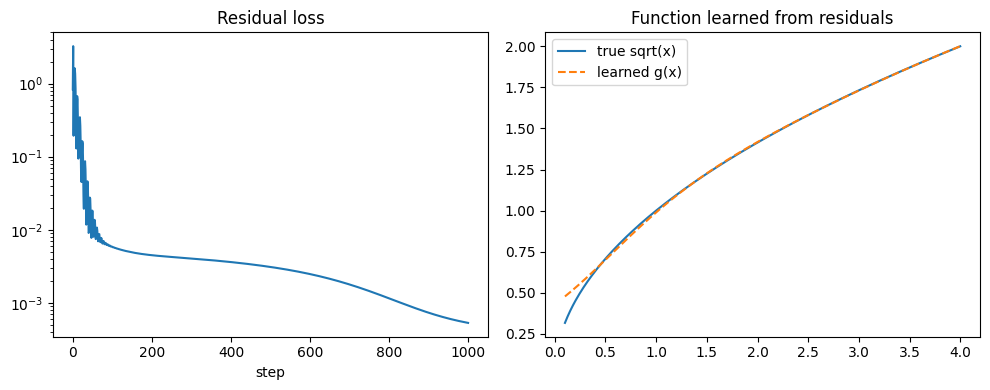

In [15]:
g_pred = residual_model.predict(x_data, verbose=0)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.yscale("log")
plt.title("Residual loss")
plt.xlabel("step")

plt.subplot(1, 2, 2)
plt.plot(x_data, np.sqrt(x_data), label="true sqrt(x)")
plt.plot(x_data, g_pred, "--", label="learned g(x)")
plt.legend()
plt.title("Function learned from residuals")

plt.tight_layout()
plt.show()


### Residual Minimization and MMW / KS

The toy example is:

```text
state x -> neural network g(x) -> residual g(x)^2 - x -> loss
```

MMW / KS code follows the same pattern:

```text
state variables -> neural-network decision rules -> Euler/model residuals -> loss
```

The later notebooks only have more state variables, more economic equations, and more complicated residuals.


## 9. What Is `@tf.function`?

In the reference code you may see:

```python
@tf.function
def some_function(...):
    ...
```

Interpretation: TensorFlow compiles the Python function into a faster computational graph.

For this tutorial, you only need to know:

- it can improve speed;
- during debugging, temporarily removing `@tf.function` can make error messages easier to interpret.


In [16]:
@tf.function
def square_plus_one(x):
    return x ** 2 + 1.0

print(square_plus_one(tf.constant([1.0, 2.0, 3.0])).numpy())


[ 2.  5. 10.]


## 10. Minimal TensorFlow / PyTorch / JAX Comparison (Optional)

The main track is TensorFlow.

This optional section only shows that all three frameworks can create variables and compute gradients.

If PyTorch or JAX is not installed, skip this section.


In [17]:
# TensorFlow: d(x^2)/dx at x=3
x = tf.Variable(3.0)
with tf.GradientTape() as tape:
    y = x ** 2
print("TensorFlow gradient:", tape.gradient(y, x).numpy())


TensorFlow gradient: 6.0


In [18]:
# PyTorch optional comparison
try:
    import torch
    x = torch.tensor(3.0, requires_grad=True)
    y = x ** 2
    y.backward()
    print("PyTorch gradient:", x.grad.item())
except Exception as e:
    print("PyTorch is not available or failed to run:", repr(e))


PyTorch gradient: 6.0


In [19]:
# JAX optional comparison
try:
    import jax
    grad_fn = jax.grad(lambda x: x ** 2)
    print("JAX gradient:", float(grad_fn(3.0)))
except Exception as e:
    print("JAX is not available or failed to run:", repr(e))


JAX gradient: 6.0


## 11. Reading Tips Before MMW / KS

When moving to notebooks 03 and 04, students do not need to understand every line on the first pass. First follow the common structure:

```text
state variables -> neural network -> decision variables
model equations + decision variables -> residuals / Euler errors
residuals -> loss / objective
optimizer step -> update neural-network parameters
```

During the tutorial, the instructor will guide students through the classroom versions of notebooks 03 and 04 and explain how the main code blocks correspond to the model equations or solution objects in the paper. Full training and slower plotting sections are after-class tasks.
